In [1]:
#!/usr/bin/env python
# coding: utf-8

# ### Ce-bigFISH: image analysis toolkit for *C. elegans* embryo

# #### Input image info:

# In[13]:


# # # Parameters if running with sbatch script
import os

# # # Retrieve parameters from environment variables
# folder_name = os.getenv('FOLDER_NAME')
# output_directory = os.getenv('OUTPUT_DIRECTORY')

# # Channels
# Cy5 = os.getenv('Cy5')
# mCherry = os.getenv('mCherry')
# FITC = os.getenv('FITC')
# DAPI = os.getenv('DAPI')
# brightfield = os.getenv('brightfield')

# # Microscope parameters
# wavelength_cy5 = int(os.getenv('wavelength_cy5', 670))
# wavelength_mCherry = int(os.getenv('wavelength_mCherry', 610))
# na = float(os.getenv('na', 1.42))
# refractive_index_medium = float(os.getenv('refractive_index_medium', 1.515))

# # PSF parameters
# psf_calculator = os.getenv('PSF_CALCULATOR', 'False') == 'True'
# spot_radius_ch0 = tuple(map(int, os.getenv('SPOT_RADIUS_CH0', '1409,340,340').split(',')))
# spot_radius_ch1 = tuple(map(int, os.getenv('SPOT_RADIUS_CH1', '1283,310,310').split(',')))
# voxel_size = tuple(map(int, os.getenv('VOXEL_SIZE', '1448,450,450').split(',')))

# # Image type selection
# dv_images = os.getenv('DV_IMAGES', 'True') == 'True'
# nd2_images = os.getenv('ND2_IMAGES', 'False') == 'True'
# tiff_images = os.getenv('TIFF_IMAGES', 'False') == 'True'


# # Feature selection (convert string "True"/"False" to boolean)
# segmentation = os.getenv('SEGMENTATION', 'True') == 'True'
# spot_detection = os.getenv('SPOT_DETECTION', 'True') == 'True'

# run_mRNA_heatmaps = os.getenv('RUN_mRNA_HEATMAPS', 'True') == 'True'
# run_protein_heatmaps = os.getenv('RUN_PROTEIN_HEATMAPS', 'True') == 'True'
# analyze_rna_density = os.getenv('ANALYZE_RNA_DENSITY', 'False') == 'True'

# generate_donut_mask = os.getenv('GENERATE_DONUT_MASK', 'True') == 'True'
# generate_pgranule_mask = os.getenv('GENERATE_PGRANULE_MASK', 'True') == 'True'

# calculate_membrane_colocalization = os.getenv('CALCULATE_MEMBRANE_COLOCALIZATION', 'True') == 'True'
# calculate_nuclei_colocalization = os.getenv('CALCULATE_NUCLEI_COLOCALIZATION', 'True') == 'True'
# calculate_pgranule_colocalization = os.getenv('CALCULATE_PGRANULE_COLOCALIZATION', 'True') == 'True'
# calculate_mRNA_mRNA_colocalization = os.getenv('CALCULATE_mRNA_mRNA_COLOCALIZATION', 'True') == 'True'

# # Ensure required parameters are set
# if folder_name is None or output_directory is None:
#     raise ValueError("Both 'FOLDER_NAME' and 'OUTPUT_DIRECTORY' must be provided.")

# # Print parameters to verify
# print(f"Processing folder: {folder_name}")
# print(f"Output directory: {output_directory}")
# print(f"Image types: dv={dv_images}, nd2={nd2_images}, tiff={tiff_images}")
# print(f"Channels: Cy5={Cy5}, mCherry={mCherry}, FITC={FITC}, DAPI={DAPI}, Brightfield={brightfield}")
# print(f"Microscope info: Wavelengths (Cy5={wavelength_cy5} nm, mCherry={wavelength_mCherry} nm), NA={na}, Refractive Index={refractive_index_medium}")
# print(f"PSF parameters: spot_radius_ch0={spot_radius_ch0}, spot_radius_ch1={spot_radius_ch1}, voxel_size={voxel_size}")
# print(f"Feature selection: PSF={psf_calculator}, Segmentation={segmentation}, Spot Detection={spot_detection}")
# print(f"Heatmaps: mRNA={run_mRNA_heatmaps}, Protein={run_protein_heatmaps}, RNA Density={analyze_rna_density}")
# print(f"Masks: Donut={generate_donut_mask}, P-Granule={generate_pgranule_mask}")
# print(f"Colocalization: Membrane={calculate_membrane_colocalization}, Nuclei={calculate_nuclei_colocalization}, P-Granule={calculate_pgranule_colocalization}, mRNA-mRNA={calculate_mRNA_mRNA_colocalization}")




In [2]:
#Parameters if running as jupyter notebook
# Note: input directory = image subdiorectory

#Select image type
dv_images = False
nd2_images = True
tiff_images = False

# # Note: input directory = image subdiorectory
folder_name = '/pl/active/onishimura_lab/PROJECTS/naly/bigfish/nd2-nikon_files/01_caroline_troubleshooting/no_report_chs-1/input/1047'
# folder_name = '/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_RNAi_quantification/LP306_membrane/L4440_RNAi/240122_LP306_L4440-rep2/input/01' #your folder should contain 2 images (.dv and its ref.dv)
# mask_folder = '/pl/active/onishimura_lab/PROJECTS/naly/bigfish/tiff-test'

# User-defined channel names (set to None if the channel does not exist)
Cy5 = "set-3_mRNA"  # (Q670)
mCherry = "erm-1_mRNA"  # (Q610)
FITC = "PH-GFP"  # (GFP)
DAPI = "DAPI"
brightfield = "brightfield"

#info about your microscope
wavelength_cy5 = 670 # emmision peak in nm    #dv Cy5 emission = 670
wavelength_mCherry = 610  # emmision peak in nm    #dv mcherry emission = 610
na = 1.42  # numerical aperture of microscope   # dv na = 1.42
refractive_index_medium = 1.518 # oil refractive index  #dv ri 1.515

#Select features to calculate
psf_calculator = False
spot_radius_ch0 = (1409, 340, 340)  # PSF Z,Y,X #Settings used for dv analysis so far 250218 (1409, 340, 340)
spot_radius_ch1 = (1283, 310, 310)  # PSF Z,Y,X #Settings used for dv analysis so far 250218 (1283, 310, 310)
voxel_size = (1448, 450, 450)   # Microscope pixel size in nm (Z,Y,X) #Settings used for dv analysis so far 250218 (1448, 450, 450)

segmentation = True
run_spot_detection = True

run_mRNA_heatmaps = True
run_protein_heatmaps = True
analyze_rna_density = True

generate_donut_mask = True
generate_pgranule_mask = True

calculate_membrane_colocalization = True
calculate_nuclei_colocalization = True
calculate_pgranule_colocalization = False
calculate_mRNA_mRNA_colocalization = False


#Specify where the data will be stored
output_directory = os.path.join(os.path.dirname(os.path.dirname(folder_name)), "output", os.path.basename(folder_name))
os.makedirs(output_directory, exist_ok=True)


In [3]:
# PSF calculator 
if psf_calculator:
    # #ch0 - 670 channel (Cy5)
    # Calculate lateral PSF for Cy5 channel using Em λ
    fwhm_xy_cy5 = 0.61 * wavelength_cy5 / na
    # Calculate axial PSF for Cy5 channel
    fwhm_z_cy5 = 2 * refractive_index_medium * wavelength_cy5 / na**2
    # # Print the result
    print(f"Lateral (xy) PSF for Cy5 channel: {fwhm_xy_cy5} nm")
    print(f"Axial (z) PSF for Cy5 channel with 60x oil objective: {fwhm_z_cy5} nm")


    # #ch1 - mCherry channel
    # Calculate lateral PSF for mCherry using Em λ
    fwhm_xy = 0.61 * wavelength_mCherry / na
    # Calculate axial PSF
    fwhm_z = 2 * refractive_index_medium * wavelength_mCherry / na**2
    # # Print the result
    print(f"Lateral (xy) PSF: {fwhm_xy} nm")
    print(f"Axial (z) PSF with 60x oil objective: {fwhm_z} nm")



In [4]:
#import packages:
import os
import matplotlib.pyplot as plt
import numpy as np

import tifffile
import bigfish
import bigfish.stack as stack
import bigfish.plot as plot
import bigfish.multistack as multistack
import bigfish.detection as detection

import cellpose
from cellpose import models
# from cellpose import plot
import pandas as pd
import skimage
from skimage.measure import label, regionprops
from skimage.morphology import square, dilation,erosion
from skimage import measure, morphology
from skimage.morphology import disk, binary_erosion


from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from PIL import Image

import plotly.graph_objects as go
from skimage.morphology import disk, binary_erosion

from skimage.transform import resize
from matplotlib.colors import ListedColormap


import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import cv2
import tifffile
import tifffile as tiff

# pip install plotly
# pip install ipywidgets
# pip install ipympl

# pip install nd2
import nd2

from mpl_toolkits.mplot3d import Axes3D
import cv2
import matplotlib.patches as patches
from scipy.ndimage import rotate
from scipy.ndimage import center_of_mass

import multiprocessing as mp

from IPython.display import Audio
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from scipy.ndimage import label

from skimage import measure, morphology
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize


from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom


In [5]:
# #Read in Deltavision files

if dv_images:
    # Reading the microscopy data
    current_directory = os.getcwd()
    folder_path = os.path.join(current_directory, folder_name)

    if os.path.exists(folder_path):
        # List the files in the folder
        list_filenames = os.listdir(folder_path)
        list_filenames = sorted(list_filenames)
        path_files = [os.path.join(folder_path, filename) for filename in list_filenames if not filename.startswith('.ipynb_checkpoints')]

        # Read DV files and store image stacks in list_images
        list_images = []
        for image in path_files:
            image_stack = stack.read_dv(image)
            list_images.append(image_stack)

    # Extract Image ID by removing the "_R3D_REF.dv" suffix
    dv_filename = list_filenames[1]
    if dv_filename.endswith("_R3D_REF.dv"):
        image_name = dv_filename[:-len("_R3D_REF.dv")]
    else:
        image_name = dv_filename
    print(f'Image ID: {image_name}', '\n')

    # Converting the image to a specific shape
    bf = list_images[1]  # [C,Z,Y,X]
    image_colors = list_images[0]  # Reference [Y,X]

    bf = bf.astype(np.uint16)
    image_colors = image_colors.astype(np.uint16)

    print(f'Image colors \n{list_filenames[0]}: {image_colors.shape} \n')
    print(f'Brightfield \n{list_filenames[1]}: {bf.shape}')
        
        
    # Explicitly assign channels from image_colors and bf
    Cy5_array = image_colors[0, :, :, :] if image_colors[0] is not None else None
    mCherry_array = image_colors[1, :, :, :] if image_colors[1] is not None else None
    FITC_array = image_colors[2, :, :, :] if image_colors[2] is not None else None
    nuclei_array = image_colors[3, :, :, :] if image_colors[3] is not None else None
    bf = bf if brightfield is not None else None


    # Explicitly assign channels from image_colors and bf
    image_Cy5 = np.max(image_colors[0, :, :, :], axis=0) if image_colors[0] is not None else None
    image_mCherry = np.max(image_colors[1, :, :, :], axis=0) if image_colors[1] is not None else None
    image_FITC = np.max(image_colors[2, :, :, :], axis=0) if image_colors[2] is not None else None
    image_nuclei = np.max(image_colors[3, :, :, :], axis=0) if image_colors[3] is not None else None
    bf = bf if brightfield is not None else None

    # Combine images into a list
    images = [image_Cy5, image_mCherry, image_FITC, image_nuclei, bf]
    titles = [Cy5, mCherry, FITC, DAPI, brightfield]

    # Filter out None entries
    filtered_images = [(img, title) for img, title in zip(images, titles) if img is not None]

    # Plot the filtered images
    fig, ax = plt.subplots(1, len(filtered_images), figsize=(6 * len(filtered_images), 8))

    # Ensure ax is iterable
    if len(filtered_images) == 1:
        ax = [ax]

    for i, (img, title) in enumerate(filtered_images):
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(title, size=20)
        ax[i].axis("off")

    # Adjust layout and save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f'colors_{image_name}.png'))
    plt.show()
    
    
grid_width=80
grid_height=80


Image ID: 70924_1047_crop.nd2

Image colors 
70924_1047_crop.nd2: (57, 5, 900, 1300)



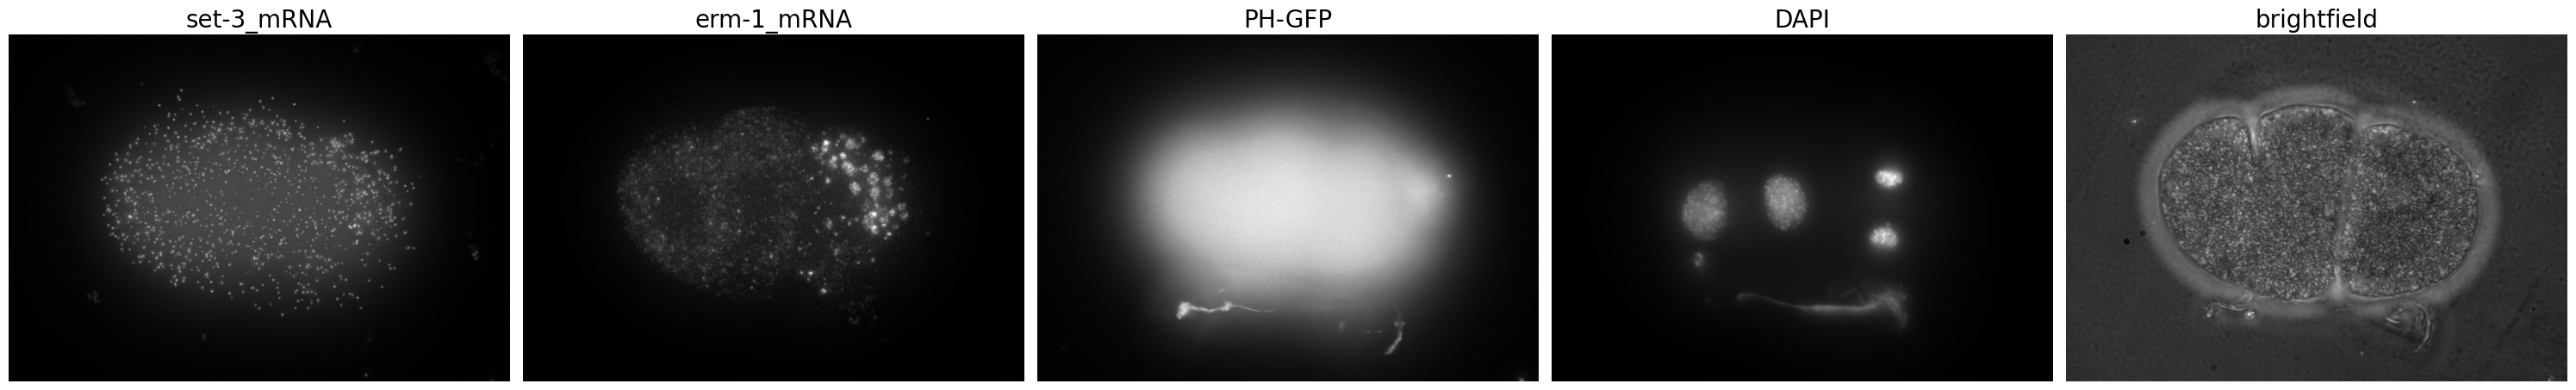

In [6]:
# Process nd2 images

if nd2_images:
    # Reading the microscopy data
    current_directory = os.getcwd()
    folder_path = os.path.join(current_directory, folder_name)

    if os.path.exists(folder_path):
        # List the files in the folder
        list_filenames = os.listdir(folder_path)
        list_filenames = sorted(list_filenames)
        path_files = [
            os.path.join(folder_path, filename)
            for filename in list_filenames
            if not filename.startswith(".ipynb_checkpoints")
        ]

        # Read ND2 files and store image stacks in list_images
        list_images = []
        for image in path_files:
            image_stack = nd2.imread(image)  # Read ND2 image
            list_images.append(image_stack)

    # Extract Image ID
    image_name = list_filenames[0]
    print(f"Image ID: {image_name}\n")

    # Check the dimensions of the first image stack
    image_colors = list_images[0]  # Example shape: [T, C, Y, X]
    print(f"Image colors \n{list_filenames[0]}: {image_colors.shape}\n")


    # Define channel names and process max projections
    channels = [Cy5, mCherry, FITC, DAPI, brightfield]
    titles = channels

    # Explicitly assign channels from image_colors and bf
    Cy5_array = image_colors[:, 0, :, :] if image_colors[0] is not None else None
    mCherry_array = image_colors[:, 1, :, :] if image_colors[1] is not None else None
    FITC_array = image_colors[:, 2, :, :] if image_colors[2] is not None else None
    nuclei_array = image_colors[:, 3, :, :] if image_colors[3] is not None else None
    bf = image_colors[:, 4, :, :] if image_colors[4] is not None else None
    
    # Explicitly process each channel
    image_Cy5 = np.max(image_colors[:, 0, :, :], axis=0) if Cy5 else None
    image_mCherry = np.max(image_colors[:, 1, :, :], axis=0) if mCherry else None
    image_FITC = np.max(image_colors[:, 2, :, :], axis=0) if FITC else None
    image_nuclei = np.max(image_colors[:, 3, :, :], axis=0) if DAPI else None
    bf = np.max(image_colors[:, 4, :, :], axis=0) if brightfield else None ## something diff here

    # Combine the images into a list
    images = [image_Cy5, image_mCherry, image_FITC, image_nuclei, bf]

    # Filter out None entries
    filtered_images = [(img, title) for img, title in zip(images, titles) if img is not None]

    # Plotting the images
    fig, ax = plt.subplots(1, len(filtered_images), figsize=(6 * len(filtered_images), 8))

    # Ensure ax is always iterable, even if there's only one plot
    if len(filtered_images) == 1:
        ax = [ax]

    for i, (img, title) in enumerate(filtered_images):
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(title, size=20)
        ax[i].axis("off")

    # Adjust layout and save the plots in the results folder
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, "colors_" + image_name + ".png"))
    plt.show()
    
grid_width=80
grid_height=60


In [7]:
# Additional functions used for segmentation
def is_nucleus_in_cytosol(mask_n, mask_c):
    mask_n[mask_n>1]=1
    mask_c[mask_c>1]=1
    size_mask_n = np.count_nonzero(mask_n)
    size_mask_c = np.count_nonzero(mask_c)
    min_size =np.min( (size_mask_n,size_mask_c) )
    mask_combined =  mask_n + mask_c
    sum_mask = np.count_nonzero(mask_combined[mask_combined==2])
    if (sum_mask> min_size*0.8) and (min_size>200): # the element is inside if the two masks overlap over the 80% of the smaller mask.
        return 1
    else:
        return 0
    
def remove_lonely_masks(masks_0, masks_1,is_nuc=None):
    n_mask_0 = np.max(masks_0)
    n_mask_1 = np.max(masks_1)
    if (n_mask_0>0) and (n_mask_1>0):
        for ind_0 in range(1,n_mask_0+1):
            tested_mask_0 = erosion(np.where(masks_0 == ind_0, 1, 0))
            array_paired= np.zeros(n_mask_1)
            for ind_1 in range(1,n_mask_1+1):
                tested_mask_1 = erosion(np.where(masks_1 == ind_1, 1, 0))
                array_paired[ind_1-1] = is_nucleus_in_cytosol(tested_mask_1, tested_mask_0)
                if (is_nuc =='nuc') and (np.count_nonzero(tested_mask_0) > np.count_nonzero(tested_mask_1) ):
                    # condition that rejects images with nucleus bigger than the cytosol
                    array_paired[ind_1-1] = 0
                elif (is_nuc is None ) and (np.count_nonzero(tested_mask_1) > np.count_nonzero(tested_mask_0) ):
                    array_paired[ind_1-1] = 0
            if any (array_paired) == False: # If the cytosol is not associated with any mask.
                masks_0 = np.where(masks_0 == ind_0, 0, masks_0)
            masks_with_pairs = masks_0
    else:
        masks_with_pairs = np.zeros_like(masks_0)
    return masks_with_pairs

def matching_masks(masks_cyto, masks_nuclei):
    n_mask_cyto = np.max(masks_cyto)
    n_mask_nuc = np.max(masks_nuclei)
    new_masks_nuclei = np.zeros_like(masks_cyto)
    reordered_mask_nuclei = np.zeros_like(masks_cyto)
    if (n_mask_cyto>0) and (n_mask_nuc>0):
        for mc in range(1,n_mask_cyto+1):
            tested_mask_cyto = np.where(masks_cyto == mc, 1, 0)
            for mn in range(1,n_mask_nuc+1):
                mask_paired = False
                tested_mask_nuc = np.where(masks_nuclei == mn, 1, 0)
                mask_paired = is_nucleus_in_cytosol(tested_mask_nuc, tested_mask_cyto)
                if mask_paired == True:
                    if np.count_nonzero(new_masks_nuclei) ==0:
                        new_masks_nuclei = np.where(masks_nuclei == mn, -mc, masks_nuclei)
                    else:
                        new_masks_nuclei = np.where(new_masks_nuclei == mn, -mc, new_masks_nuclei)
            reordered_mask_nuclei = np.absolute(new_masks_nuclei)
    return reordered_mask_nuclei

def remove_extreme_values(image,min_percentile=0.1, max_percentile=99.5):
    max_val = np.percentile(image, max_percentile)
    min_val = np.percentile(image, min_percentile)
    image [image < min_val] = min_val
    image [image > max_val] = max_val
    return image

def metric_max_cells_and_area( masks):
    n_masks = np.max(masks)
    if n_masks > 1: # detecting if more than 1 mask are detected per cell
        size_mask = []
        for nm in range (1, n_masks+1): # iterating for each mask in a given cell. The mask has values from 0 for background, to int n, where n is the number of detected masks.
            approximated_radius = np.sqrt(np.sum(masks == nm)/np.pi)  # a=  pi r2
            size_mask.append(approximated_radius) #np.sum(masks == nm)) # creating a list with the size of each mask
        size_masks_array = np.array(size_mask)
        metric = np.mean(size_masks_array).astype(int) * n_masks
    elif n_masks == 1: # do nothing if only a single mask is detected per image.
        approximated_radius = np.sqrt(np.sum(masks == 1)/np.pi) 
        metric = approximated_radius.astype(int)
    else:  # return zero if no mask are detected
        metric = 0  
    return metric   

def nuclear_segmentation(image_nuclei):
    MIN_CELL_SIZE = 1000
    list_masks_nuclei = []
    list_thresholds = np.arange(0.7,0.95, 0.05) # for nd2 images
    array_number_detected_masks = np.zeros(len(list_thresholds))
    for i,tested_ts in enumerate(list_thresholds):
        image_nuclei_binary = image_nuclei.copy()
        max_value_image = np.max(image_nuclei_binary)
        image_nuclei_binary[image_nuclei_binary < max_value_image*tested_ts] = 0
        image_nuclei_binary[image_nuclei_binary > max_value_image*tested_ts] = 1
        labels = measure.label(image_nuclei_binary)
        filtered_labels = morphology.remove_small_objects(labels, min_size=MIN_CELL_SIZE)
        unique_filtered_labels = np.unique(filtered_labels)
        tested_masks_nuclei = np.zeros_like(filtered_labels)
        for idx, old_label in enumerate(unique_filtered_labels):
            tested_masks_nuclei[filtered_labels == old_label] = idx
        list_masks_nuclei.append(tested_masks_nuclei)
        array_number_detected_masks[i]= metric_max_cells_and_area( tested_masks_nuclei) 
    selected_index = np.argmax(array_number_detected_masks)
    masks_nuclei = list_masks_nuclei [selected_index]
    return masks_nuclei

def cytosol_segmentation(image_cytosol,second_image_cytosol,cytosol_diameter):
    flow_ts=1
    MIN_CELL_SIZE = 1000
    model = models.Cellpose(gpu=True, model_type='cyto2') # model_type='cyto', 'cyto2' or model_type='nuclei'
    if not (second_image_cytosol is None):
        merged_image_cytosol = np.concatenate((image_cytosol[:, :, np.newaxis], second_image_cytosol[:, :, np.newaxis]), axis=2)
        masks_cytosol_unfiltered = model.eval(merged_image_cytosol, diameter=cytosol_diameter, flow_threshold=flow_ts, channels=[0,1])[0]
    else:
        masks_cytosol_unfiltered = model.eval(image_cytosol, diameter=cytosol_diameter, flow_threshold=flow_ts, channels=[0,0])[0]
    filtered_cyto = morphology.remove_small_objects(masks_cytosol_unfiltered, min_size=MIN_CELL_SIZE)
    unique_filtered_cyto = np.unique(filtered_cyto)
    masks_cytosol = np.zeros_like(filtered_cyto)
    for idx, old_label in enumerate(unique_filtered_cyto):
        masks_cytosol[filtered_cyto == old_label] = idx
    return masks_cytosol



In [8]:
def segmentation_optimization(image_cytosol,image_nuclei,cytosol_diameter,second_image_cytosol=None):
    # Cytosol segmentation
    masks_cytosol =cytosol_segmentation(image_cytosol,second_image_cytosol,cytosol_diameter)
    # Nuclear segmentation
    masks_nuclei = nuclear_segmentation(image_nuclei)
    # reordering nuclei masks
    masks_nuclei = matching_masks(masks_cytosol,masks_nuclei)
    # remove masks without nuclei
    masks_nuclei= remove_lonely_masks(masks_0=masks_nuclei , masks_1=masks_cytosol,is_nuc='nuc')
    masks_cytosol= remove_lonely_masks(masks_0=masks_cytosol , masks_1=masks_nuclei)
    # calculate size of masks
    number_masks_cyto = np.max(masks_cytosol)
    list_masks_cyto_sizes =[]
    for i in range (1, number_masks_cyto+1):
        list_masks_cyto_sizes.append(len(masks_cytosol[masks_cytosol==i]) )
    number_masks_nuc = np.max(masks_nuclei)
    list_masks_nuc_sizes =[]
    for i in range (1, number_masks_nuc+1):
        list_masks_nuc_sizes.append(len(masks_nuclei[masks_nuclei==i]) )
    return masks_nuclei, masks_cytosol,list_masks_nuc_sizes, list_masks_cyto_sizes



In [9]:
# Codes used to segment the nucleus and the cytosol
def segmentation(image_cytosol,image_nuclei, second_image_cytosol=None):
    # removing outliers in image
    image_cytosol = remove_extreme_values(image=image_cytosol,min_percentile=0.1, max_percentile=99.5) #0.1 #99.5
    if not (second_image_cytosol is None):
        second_image_cytosol = remove_extreme_values(image=second_image_cytosol,min_percentile=0.1, max_percentile=99.5)
    image_nuclei = remove_extreme_values(image=image_nuclei,min_percentile=0.1, max_percentile=99.5)
    # Optimization segmentation
    list_masks_nuclei = []
    list_masks_cytosol=[]
    list_masks_nuc_sizes =[]
    list_masks_cyto_sizes=[]
    list_flow_thresholds = np.arange(40, 100, 10)
    array_number_detected_masks = np.zeros(len(list_flow_thresholds))
    for i,tested_ts in enumerate(list_flow_thresholds):
        tested_masks_nuclei, tested_masks_cytosol, tested_list_masks_nuc_sizes, tested_list_masks_cyto_sizes = segmentation_optimization(image_cytosol,image_nuclei,cytosol_diameter=tested_ts,second_image_cytosol=second_image_cytosol)
        list_masks_nuclei.append(tested_masks_nuclei)
        list_masks_cytosol.append(tested_masks_cytosol)
        list_masks_nuc_sizes.append(tested_list_masks_nuc_sizes)
        list_masks_cyto_sizes.append(tested_list_masks_cyto_sizes)
        array_number_detected_masks[i]= metric_max_cells_and_area( tested_masks_cytosol) + metric_max_cells_and_area( tested_masks_nuclei)
    selected_index = np.argmax(array_number_detected_masks)
    masks_nuclei = list_masks_nuclei [selected_index]
    masks_cytosol = list_masks_cytosol [selected_index]
    masks_nuc_sizes = list_masks_nuc_sizes[selected_index]
    masks_cyto_sizes = list_masks_cyto_sizes[selected_index]
    
        # Plotting
    color_map = 'Greys_r'
    fig, ax = plt.subplots(1,4, figsize=(14, 4))
    # Plotting the heatmap of a section in the image
    ax[0].imshow(image_nuclei,cmap=color_map)
    ax[1].imshow(masks_nuclei,cmap=color_map)
    ax[2].imshow(image_cytosol,cmap=color_map)
    ax[3].imshow(masks_cytosol,cmap=color_map)
    ax[0].set(title='DAPI'); ax[0].axis('off');ax[0].grid(False)
    ax[1].set(title='mask nuclei'); ax[1].axis('off');ax[1].grid(False)
    ax[2].set(title='brightfield'); ax[2].axis('off');ax[2].grid(False)
    ax[3].set(title='mask cytosol'); ax[3].axis('off');ax[3].grid(False)
    
    return masks_cytosol, masks_nuclei, masks_cyto_sizes, masks_nuc_sizes



In [ ]:
# def nuclear_segmentation(image_nuclei):
#     MIN_CELL_SIZE = 1000
#     list_masks_nuclei = []
# #     list_thresholds = np.arange(0.7,0.95, 0.05) # for dv images
#     list_thresholds = np.arange(0.7,0.95, 0.05) # for nd2 images
#     array_number_detected_masks = np.zeros(len(list_thresholds))
#     for i,tested_ts in enumerate(list_thresholds):
#         image_nuclei_binary = image_nuclei.copy()
#         max_value_image = np.max(image_nuclei_binary)
#         image_nuclei_binary[image_nuclei_binary < max_value_image*tested_ts] = 0
#         image_nuclei_binary[image_nuclei_binary > max_value_image*tested_ts] = 1
#         labels = measure.label(image_nuclei_binary)
#         filtered_labels = morphology.remove_small_objects(labels, min_size=MIN_CELL_SIZE)
#         unique_filtered_labels = np.unique(filtered_labels)
#         tested_masks_nuclei = np.zeros_like(filtered_labels)
#         for idx, old_label in enumerate(unique_filtered_labels):
#             tested_masks_nuclei[filtered_labels == old_label] = idx
#         list_masks_nuclei.append(tested_masks_nuclei)
#         array_number_detected_masks[i]= metric_max_cells_and_area( tested_masks_nuclei) 
#     selected_index = np.argmax(array_number_detected_masks)
#     masks_nuclei = list_masks_nuclei [selected_index]
#     return masks_nuclei


In [ ]:
#### Draft for segmentation in 3D
# def cytosol_segmentation(image_cytosol, second_image_cytosol, cytosol_diameter):
#     flow_ts = 1
#     MIN_CELL_SIZE = 1000  # 100000 -> segmented the entire embryo
#     model = models.Cellpose(gpu=True, model_type='cyto2')  # model_type='cyto', 'cyto2' or 'nuclei'

#     if not (second_image_cytosol is None):
#         merged_image_cytosol = np.concatenate(
#             (image_cytosol[:, :, np.newaxis], second_image_cytosol[:, :, np.newaxis]), axis=2
#         )
#         masks_cytosol_unfiltered = model.eval(
#             merged_image_cytosol,
#             diameter=cytosol_diameter,
#             flow_threshold=flow_ts,
#             channels=[0, 1],
#             do_3D=True 
#         )[0]
#     else:
#         masks_cytosol_unfiltered = model.eval(
#             image_cytosol,
#             diameter=cytosol_diameter,
#             flow_threshold=flow_ts,
#             channels=[0, 0],
#             do_3D=True 
#         )[0]

#     filtered_cyto = morphology.remove_small_objects(masks_cytosol_unfiltered, min_size=MIN_CELL_SIZE)
#     unique_filtered_cyto = np.unique(filtered_cyto)
#     masks_cytosol = np.zeros_like(filtered_cyto)
#     for idx, old_label in enumerate(unique_filtered_cyto):
#         masks_cytosol[filtered_cyto == old_label] = idx
#     return masks_cytosol



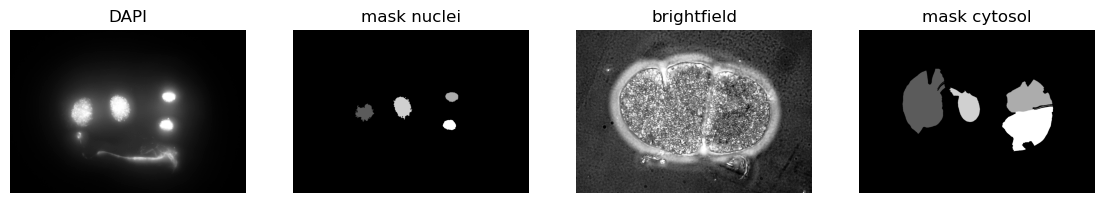

In [10]:
# # Run segmentation functions
image_cytosol = bf
second_image_cytosol = image_nuclei
masks_cytosol, masks_nuclei,list_masks_cyto_sizes, list_masks_nuc_sizes = segmentation(image_cytosol,image_nuclei,second_image_cytosol)

segmentation_filename = os.path.join(output_directory, 'segmentation_' + image_name + '.png')

# Save the figure
plt.savefig(segmentation_filename)



In [11]:
#@title Codes used for spot detection
# Note: spot radius = Point Spread Function (PSF)

def spot_detection(rna,voxel_size,spot_radius,masks_cytosol):
    spots, threshold = detection.detect_spots(
        images= rna,
        return_threshold=True,
        voxel_size=voxel_size,
        spot_radius=spot_radius) 

    spot_radius_px = detection.get_object_radius_pixel(
        voxel_size_nm=voxel_size,
        object_radius_nm=spot_radius,
        ndim=3) 

    # LoG filter
    rna_log = stack.log_filter(rna, sigma=spot_radius_px)

    # local maximum detection
    mask = detection.local_maximum_detection(rna_log, min_distance=spot_radius_px)

    # thresholding
    threshold = detection.automated_threshold_setting(rna_log, mask)
    spots, _ = detection.spots_thresholding(rna_log, mask, threshold)


    # Decompose regions by simulating as many spots as possible until we match the original region intensity.
    #spots_post_decomposition = spots.copy()
    spots_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
        image=rna,
        spots=spots,
        voxel_size=voxel_size,
        spot_radius=spot_radius,
        alpha=0.7,  # alpha impacts the number of spots per candidate region
        beta=1,  # beta impacts the number of candidate regions to decompose
        gamma=5)  # gamma the filtering step to denoise the image

    # define clusters
    spots_post_clustering, clusters = detection.detect_clusters(
        spots=spots_post_decomposition,
        voxel_size=voxel_size,
        radius=1136, #626 #1000
        nb_min_spots=5) #10

   # plotting
    print(f"Image ID: {image_name} \n")
    print(f"{rna_channel} detection")
    print(f" threshold: {threshold}")
    print("\r spots: {0}".format(spots_post_clustering.shape[0]))
    print("\r clusters: {0}".format(clusters.shape[0]))
   
        #elbow plot
    threshold_output = os.path.join(output_directory, rna_channel + '_threshold_' + image_name)
    plot.plot_elbow(
        images=rna,
        voxel_size=voxel_size,
        spot_radius=spot_radius,
        size_axes=8,
        framesize=(5, 3),
        title=(f"{rna_channel} detection threshold"),
        size_title=12,
        path_output=threshold_output,
        show=True  # Set show to False to hide the plot
    )



    #    # Save the plots in the results folder
    detection_output = os.path.join(output_directory, rna_channel + '_detection_' + image_name)
    plot.plot_detection(
        image=np.max(rna, axis=0),
        spots=[spots_post_decomposition, clusters[:, :3]],
        shape=["circle", "polygon"],
        radius=[1, 4],
        color=detection_color,
        linewidth=[3, 2],
        fill=[False, True],
        contrast=True,
        framesize=(10, 5),
        title=(f"{rna_channel} detection"),
        path_output= detection_output,
        show=True
    )

    #spots_no_ts, _, ts = multistack.remove_transcription_site(spotDetectionCSV, clusterDetectionCSV, mask_nuc, ndim=3)
    #spots_in_region, _ = multistack.identify_objects_in_region(mask, spots_post_clustering[:,:3], ndim=3)

    # Separating and counting the spots in each cell
    number_masks_cyto = np.max(masks_cytosol)
    list_spots_in_each_cell =[]
    list_clusters_in_each_cell =[]
    for i in range (1, number_masks_cyto+1):
        temp_cyto_mask= np.zeros_like(masks_cytosol)
        temp_cyto_mask[masks_cytosol == i] = i
        spots_in_region, _ = multistack.identify_objects_in_region(mask=temp_cyto_mask, coord=spots_post_clustering[:,:3], ndim=3)
        clusters_in_region,_ = multistack.identify_objects_in_region(mask=temp_cyto_mask, coord=clusters[:,:3], ndim=3)
        list_spots_in_each_cell.append(len(spots_in_region))
        list_clusters_in_each_cell.append(len( clusters_in_region ))
        del spots_in_region, clusters_in_region
    return spots_post_clustering, clusters, list_spots_in_each_cell, list_clusters_in_each_cell



Image ID: 70924_1047_crop.nd2 

set-3_mRNA detection
 threshold: 51.0
 spots: 1548
 clusters: 0


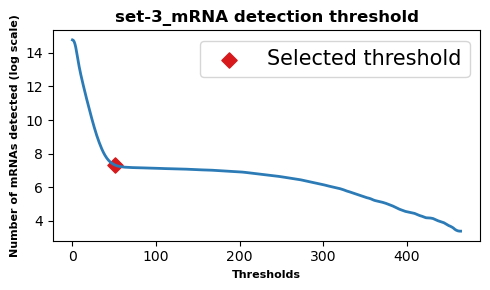

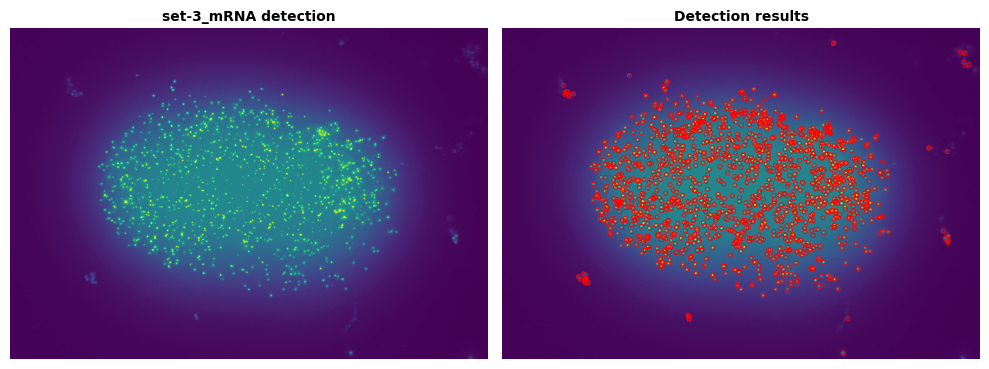

Image ID: 70924_1047_crop.nd2 

erm-1_mRNA detection
 threshold: 71.0
 spots: 12084
 clusters: 54


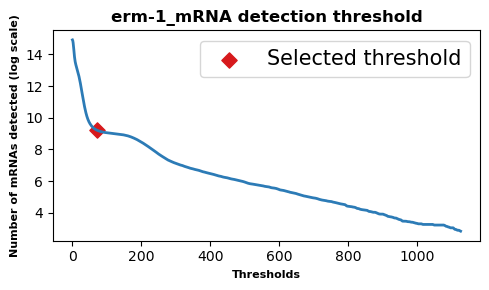

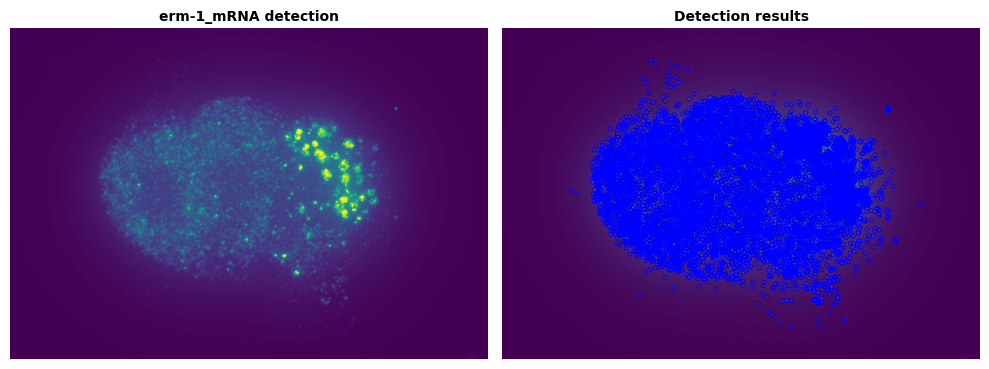

In [12]:
# #Run spot detection functions
if Cy5 is not None and image_Cy5 is not None:
    rna_ch0 = Cy5_array # [Z,Y,X,C]
#     rna_ch0 = rna_ch0.astype(np.uint16)
    rna_channel = Cy5
    detection_color = "red"
    spots_post_clustering_ch0, clusters_ch0,list_spots_in_each_cell_ch0,list_clusters_in_each_cell_ch0 = spot_detection(rna_ch0,voxel_size,spot_radius_ch0,masks_cytosol)

if mCherry is not None and image_mCherry is not None:
    rna_ch1 = mCherry_array # [Z,Y,X,C]
#     rna_ch1 = rna_ch1.astype(np.uint16)
    rna_channel = mCherry
    detection_color = "blue"
    spots_post_clustering_ch1, clusters_ch1,list_spots_in_each_cell_ch1,list_clusters_in_each_cell_ch1 = spot_detection(rna_ch1,voxel_size,spot_radius_ch1,masks_cytosol)



In [1]:
#### Classification of masks using size:


import matplotlib.pyplot as plt
# import numpy as np
# from scipy.ndimage import center_of_mass


# # list_masks_cyto_sizes
# if run_cell_segmentation:
#     def labeled_masks(masks_cytosol, list_masks_cyto_sizes):
#         # Sort mask sizes to assign AB and P1
#         sorted_indices = np.argsort(list_masks_cyto_sizes)[::-1]
#         cell_names = ['AB', 'P1', 'ABa','ABb','P2', '1', '2', '3','4']
#         label_to_name = {idx + 1: cell_names[i] for i, idx in enumerate(sorted_indices)}

#         # Use max projection if 3D
#         mask_image = np.max(masks_cytosol, axis=0) if masks_cytosol.ndim == 3 else masks_cytosol

#         # Create color overlay
#         plt.figure(figsize=(6, 6))
#         plt.imshow(mask_image, cmap='nipy_spectral')
#         plt.axis('off')

#         # Overlay text labels at center of each mask
#         for label, name in label_to_name.items():
#             y, x = center_of_mass(mask_image == label)
#             plt.text(x, y, name, color='white', fontsize=16, ha='center', va='center', weight='bold')

#         plt.title("Labeled Cytosol Masks")
#         plt.show()
#         return label_to_name
#     label_to_name = labeled_masks(masks_cytosol, list_masks_cyto_sizes)

